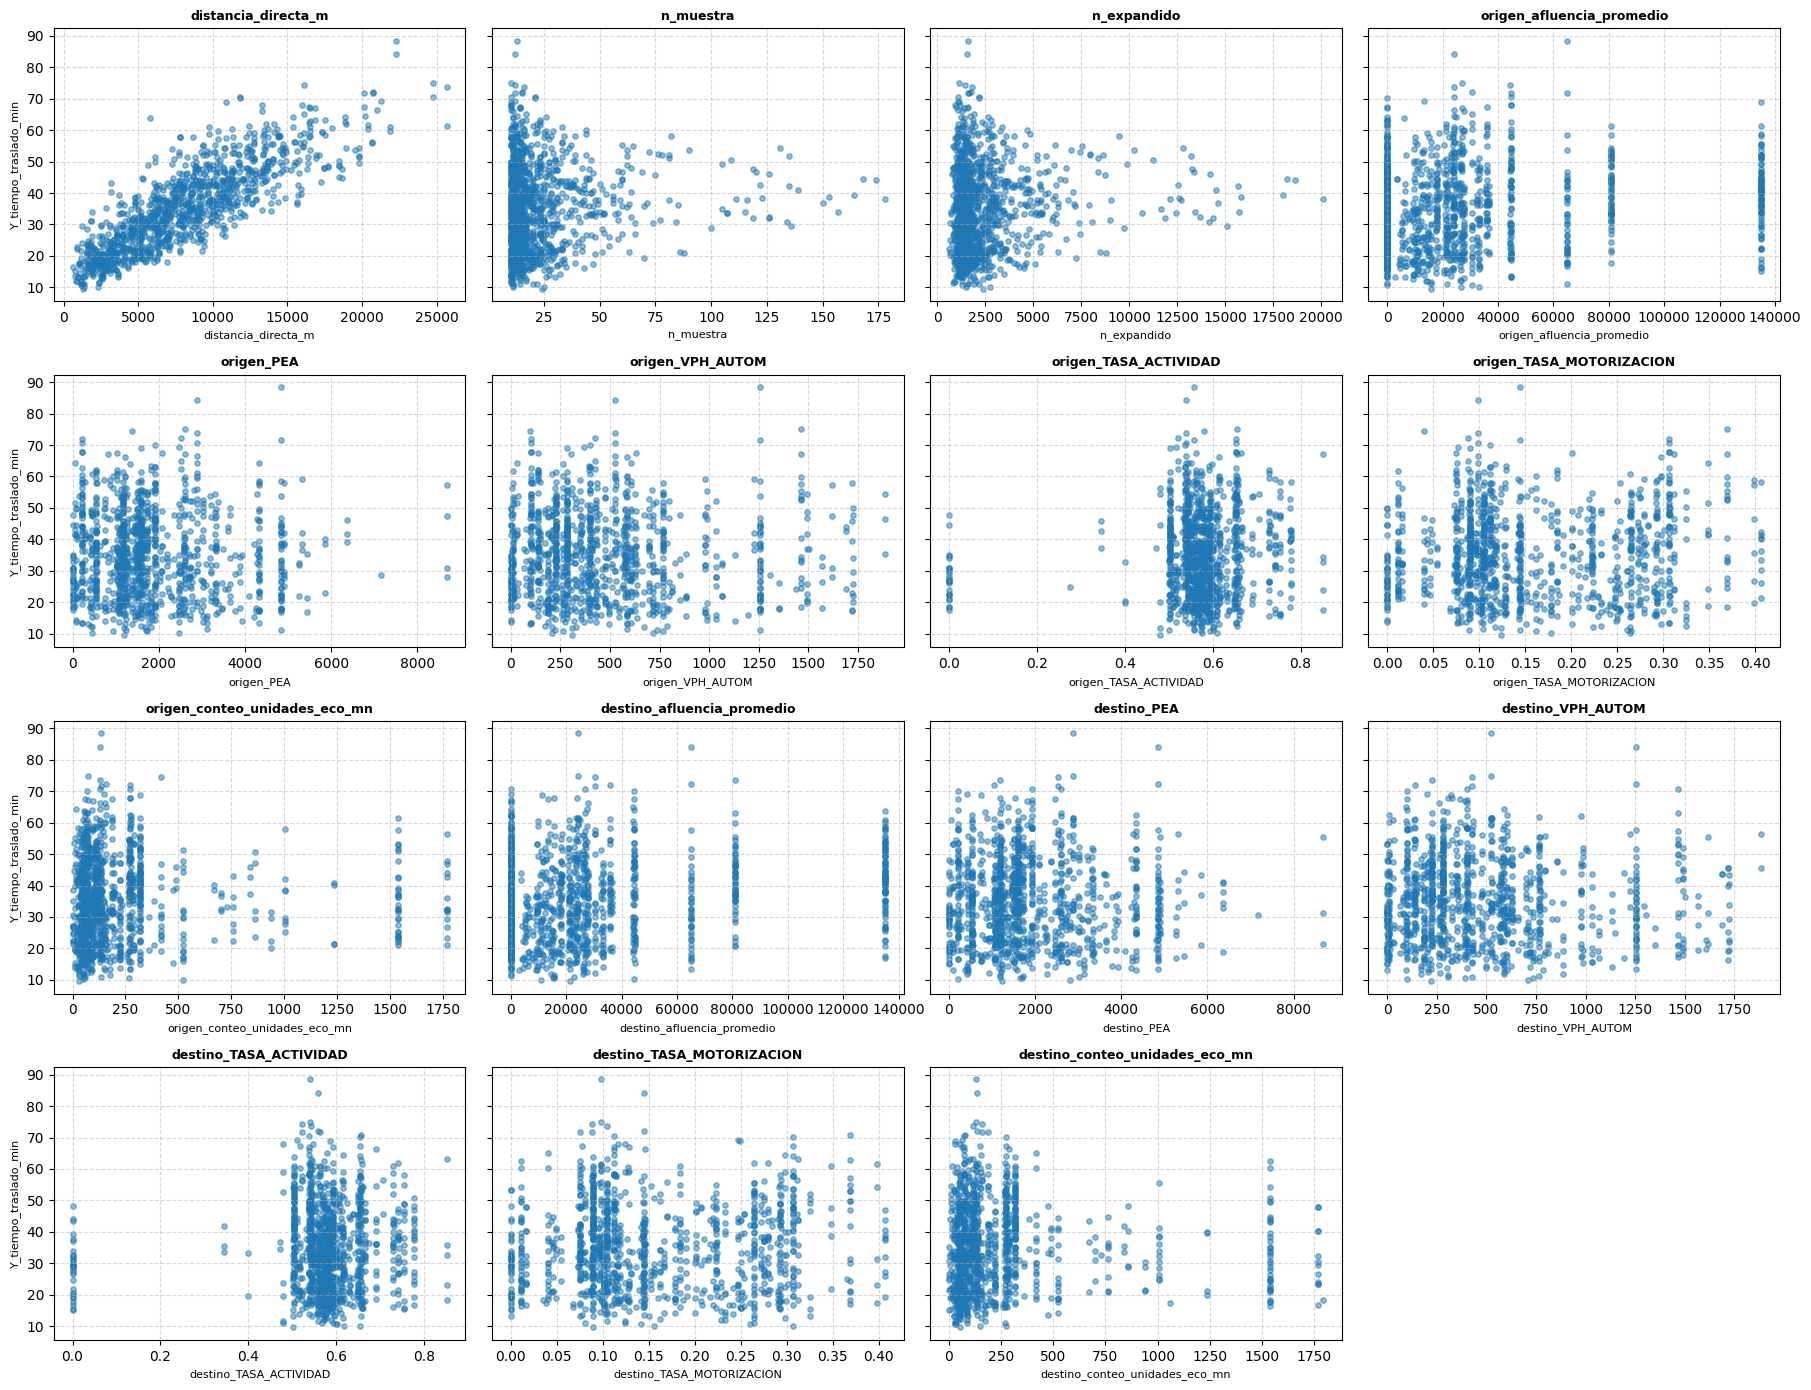

In [ ]:
import pandas as pd
import matplotlib.pyplot as plt

# 1. Cargar datos
df = pd.read_csv('dataset_final.csv')

# 2. Definir la variable objetivo Y y las variables predictoras numéricas
y = df['Y_tiempo_traslado_min']
predictores = [
    'distancia_directa_m', 'n_muestra', 'n_expandido',
    'origen_afluencia_promedio', 'origen_PEA', 'origen_VPH_AUTOM',
    'origen_TASA_ACTIVIDAD', 'origen_TASA_MOTORIZACION', 'origen_conteo_unidades_eco_mn',
    'destino_afluencia_promedio', 'destino_PEA', 'destino_VPH_AUTOM',
    'destino_TASA_ACTIVIDAD', 'destino_TASA_MOTORIZACION', 'destino_conteo_unidades_eco_mn'
]

# 3. Crear matriz de dispersión 4x4
fig, axes = plt.subplots(4, 4, figsize=(18, 14), sharey=True)
axes_flat = axes.flatten()

for i, col in enumerate(predictores):
    axes_flat[i].scatter(df[col], y, alpha=0.5, color='#1f77b4', s=15)
    axes_flat[i].set_title(col, fontweight='bold', fontsize=9)
    axes_flat[i].set_xlabel(col, fontsize=8)
    axes_flat[i].grid(True, linestyle='--', alpha=0.5)
    if i % 4 == 0:
        axes_flat[i].set_ylabel('Y_tiempo_traslado_min', fontsize=8)

# Ocultar el cuadro vacío sobrante (posición 16)
axes_flat[15].axis('off')

plt.tight_layout()
plt.show()

In [ ]:
import numpy as np
import pandas as pd

# 1. Cargar el dataset
df = pd.read_csv('dataset_final.csv')

# 2. Definir la variable objetivo Y
y = df['Y_tiempo_traslado_min']

# 3. Lista de todos los predictores numéricos
predictores = [
    'distancia_directa_m', 'n_muestra', 'n_expandido',
    'origen_afluencia_promedio', 'origen_PEA', 'origen_VPH_AUTOM',
    'origen_TASA_ACTIVIDAD', 'origen_TASA_MOTORIZACION', 'origen_conteo_unidades_eco_mn',
    'destino_afluencia_promedio', 'destino_PEA', 'destino_VPH_AUTOM',
    'destino_TASA_ACTIVIDAD', 'destino_TASA_MOTORIZACION', 'destino_conteo_unidades_eco_mn'
]

# 4. Calcular np.corrcoef para cada predictor
resultados = []

for nombre_col in predictores:
    x = df[nombre_col]

    # Calcular la matriz de correlación 2x2
    matriz_corr = np.corrcoef(y, x)

    # Extraer el coeficiente r (posición [0, 1])
    r = matriz_corr[0, 1]
    r_cuadrado = r**2

    resultados.append({
        'Variable': nombre_col,
        'r (Pearson)': r,
        'R² (Varianza Explicada)': r_cuadrado,
        'Matriz_Corr': matriz_corr
    })

# Convertir a DataFrame y ordenar por magnitud de correlación
df_corr = pd.DataFrame(resultados).sort_values(by='r (Pearson)', ascending=False)

# Imprimir resumen
print("=== COEFICIENTES DE CORRELACIÓN CON Y (Y_tiempo_traslado_min) ===\n")
print(df_corr[['Variable', 'r (Pearson)', 'R² (Varianza Explicada)']].to_string(index=False))

# Opcional: Mostrar matrices detalladas individualmente
print("\n" + "="*50)
print("MATRICES DE CORRELACIÓN INDIVIDUALES np.corrcoef(y, x):")
print("="*50)
for idx, row in df_corr.iterrows():
    print(f"\n-> Variable: {row['Variable']}")
    print(f"np.corrcoef(y, df['{row['Variable']}']):")
    print(np.round(row['Matriz_Corr'], 4))

=== COEFICIENTES DE CORRELACIÓN CON Y (Y_tiempo_traslado_min) ===

                      Variable  r (Pearson)  R² (Varianza Explicada)
           distancia_directa_m     0.842811                 0.710330
    destino_afluencia_promedio     0.186378                 0.034737
     origen_afluencia_promedio     0.145572                 0.021191
                     n_muestra     0.083847                 0.007030
                   n_expandido     0.082039                 0.006730
         origen_TASA_ACTIVIDAD     0.081568                 0.006653
      origen_TASA_MOTORIZACION     0.053949                 0.002910
        destino_TASA_ACTIVIDAD     0.044659                 0.001994
     destino_TASA_MOTORIZACION     0.034891                 0.001217
 origen_conteo_unidades_eco_mn     0.025548                 0.000653
                    origen_PEA    -0.027326                 0.000747
                   destino_PEA    -0.028188                 0.000795
destino_conteo_unidades_eco_mn    -0